In [111]:
import oursin as urchin
import pandas as pd
import numpy as np
from brainglobe_atlasapi import BrainGlobeAtlas

In [7]:
urchin.setup(id='me', localhost=True)

(urchin) Client is already connected. Use ID: me


In [165]:
urchin.ccf25.load()

(Warning) Atlas was already loaded, the renderer can have issues if you try to load an atlas twice.


In [166]:


defaults = ['FRP','MO','SS','GU','VISC','AUD','VIS','ACA','PL',
            'ILA','ORB','AI','RSP','PTLp','TEa','PERI','OLF',
            'ECT','HPF','CTXsp','CNU','BS','CB']
area_list = urchin.ccf25.get_areas(defaults)

urchin.ccf25.set_visibilities(area_list, True)
urchin.ccf25.set_materials(area_list, 'transparent-unlit')
urchin.ccf25.set_alphas(area_list, 0.15)

In [177]:
urchin.camera.main.set_background_color("#000000")
urchin.camera.main.set_rotation('angled')
urchin.camera.main.set_mode("perspective")
urchin.camera.main.set_zoom(50)

In [92]:
# Load the file data/uuid_mlapdv.csv

raw = pd.read_csv('./data/raw/uuid_mlapdv.csv')
norm = pd.read_csv('./data/baseline_normalized/uuid_mlapdv.csv')

In [93]:
raw.head()

,uuid,ml,ap,dv
0,c7d051dc-1358-422d-9eab-ca13c6b6be1b,3450.0,7937.0,3927.0
1,38bc27f2-7301-405a-a870-54e0a7b06a26,3450.0,7933.0,3908.0
2,1c4e5e11-ca9d-441a-bb8f-4b56dcc95054,3450.0,7928.0,3888.0
3,b48a90ed-84f4-424d-87ae-92c22a423777,3450.0,7928.0,3888.0
4,38a812b9-b374-46f8-ab14-3dd146411fc8,3450.0,7928.0,3888.0


In [180]:
# print the range of each of the ml ap and dv columns in raw
print(raw[['ml','ap','dv']].min())
print(raw[['ml','ap','dv']].max())

ml     860.0
ap    1804.0
dv       1.0
dtype: float64
ml     9207.0
ap    13125.0
dv     7510.0
dtype: float64


In [ ]:
atlas = BrainGlobeAtlas("allen_mouse_25um")

In [183]:
atlas.annotation.shape

(528, 320, 456)

In [161]:
# Get the colors
struct_df = pd.read_csv('./structures.csv')



def get_color(mlapdv):
    # re-order to ap/dv/ml
    apdvml = mlapdv[[1,2,0]]
    try:
        id = atlas.structure_from_coords(apdvml, microns=True)
    except IndexError:
        return '#000000'        

    if not id or id == 0:
        return '#000000'

    color = struct_df[struct_df['id'] == id]['rgb_triplet'].values[0]

    # color is a string list of int [r, g, b], convert to list of ints
    color = color[1:-1].split(', ')
    color = [int(c) for c in color]

    # convert to hex
    color = '#%02x%02x%02x' % tuple(color)
    return color

In [162]:
# Use the get_color function to get the colors from the mlapdv coordinates

raw_colors = []
for i, row in raw.iterrows():
    mlapdv = np.array(row[['ap','dv','ml']])
    raw_colors.append(get_color(mlapdv))

raw = raw.assign(color=raw_colors)

In [168]:
pmeshes = urchin.meshes.create(len(raw), interactive=False) #creates 2 primitives, stored in list pmeshes

In [175]:
# reorder to AP/ML/DV for Urchin and make a list of lists

def rn():
  return np.random.rand()*50-25

mode_black = False

coords_list = []
colors_list = []
for i, row in raw.iterrows():
  coords_list.append([row['ap']+rn(), row['ml']+rn(), row['dv']+rn()])
  colors_list.append(row['color'])

if mode_black:
  colors_list = [[0.0,0.0,0.0]]*len(raw)

sizes_list = [[0.05,0.05,0.05]]*len(raw)

urchin.meshes.set_positions(pmeshes,coords_list) #sets the positions of the primitives
urchin.meshes.set_colors(pmeshes, colors_list)
urchin.meshes.set_scales(pmeshes, sizes_list)

(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete


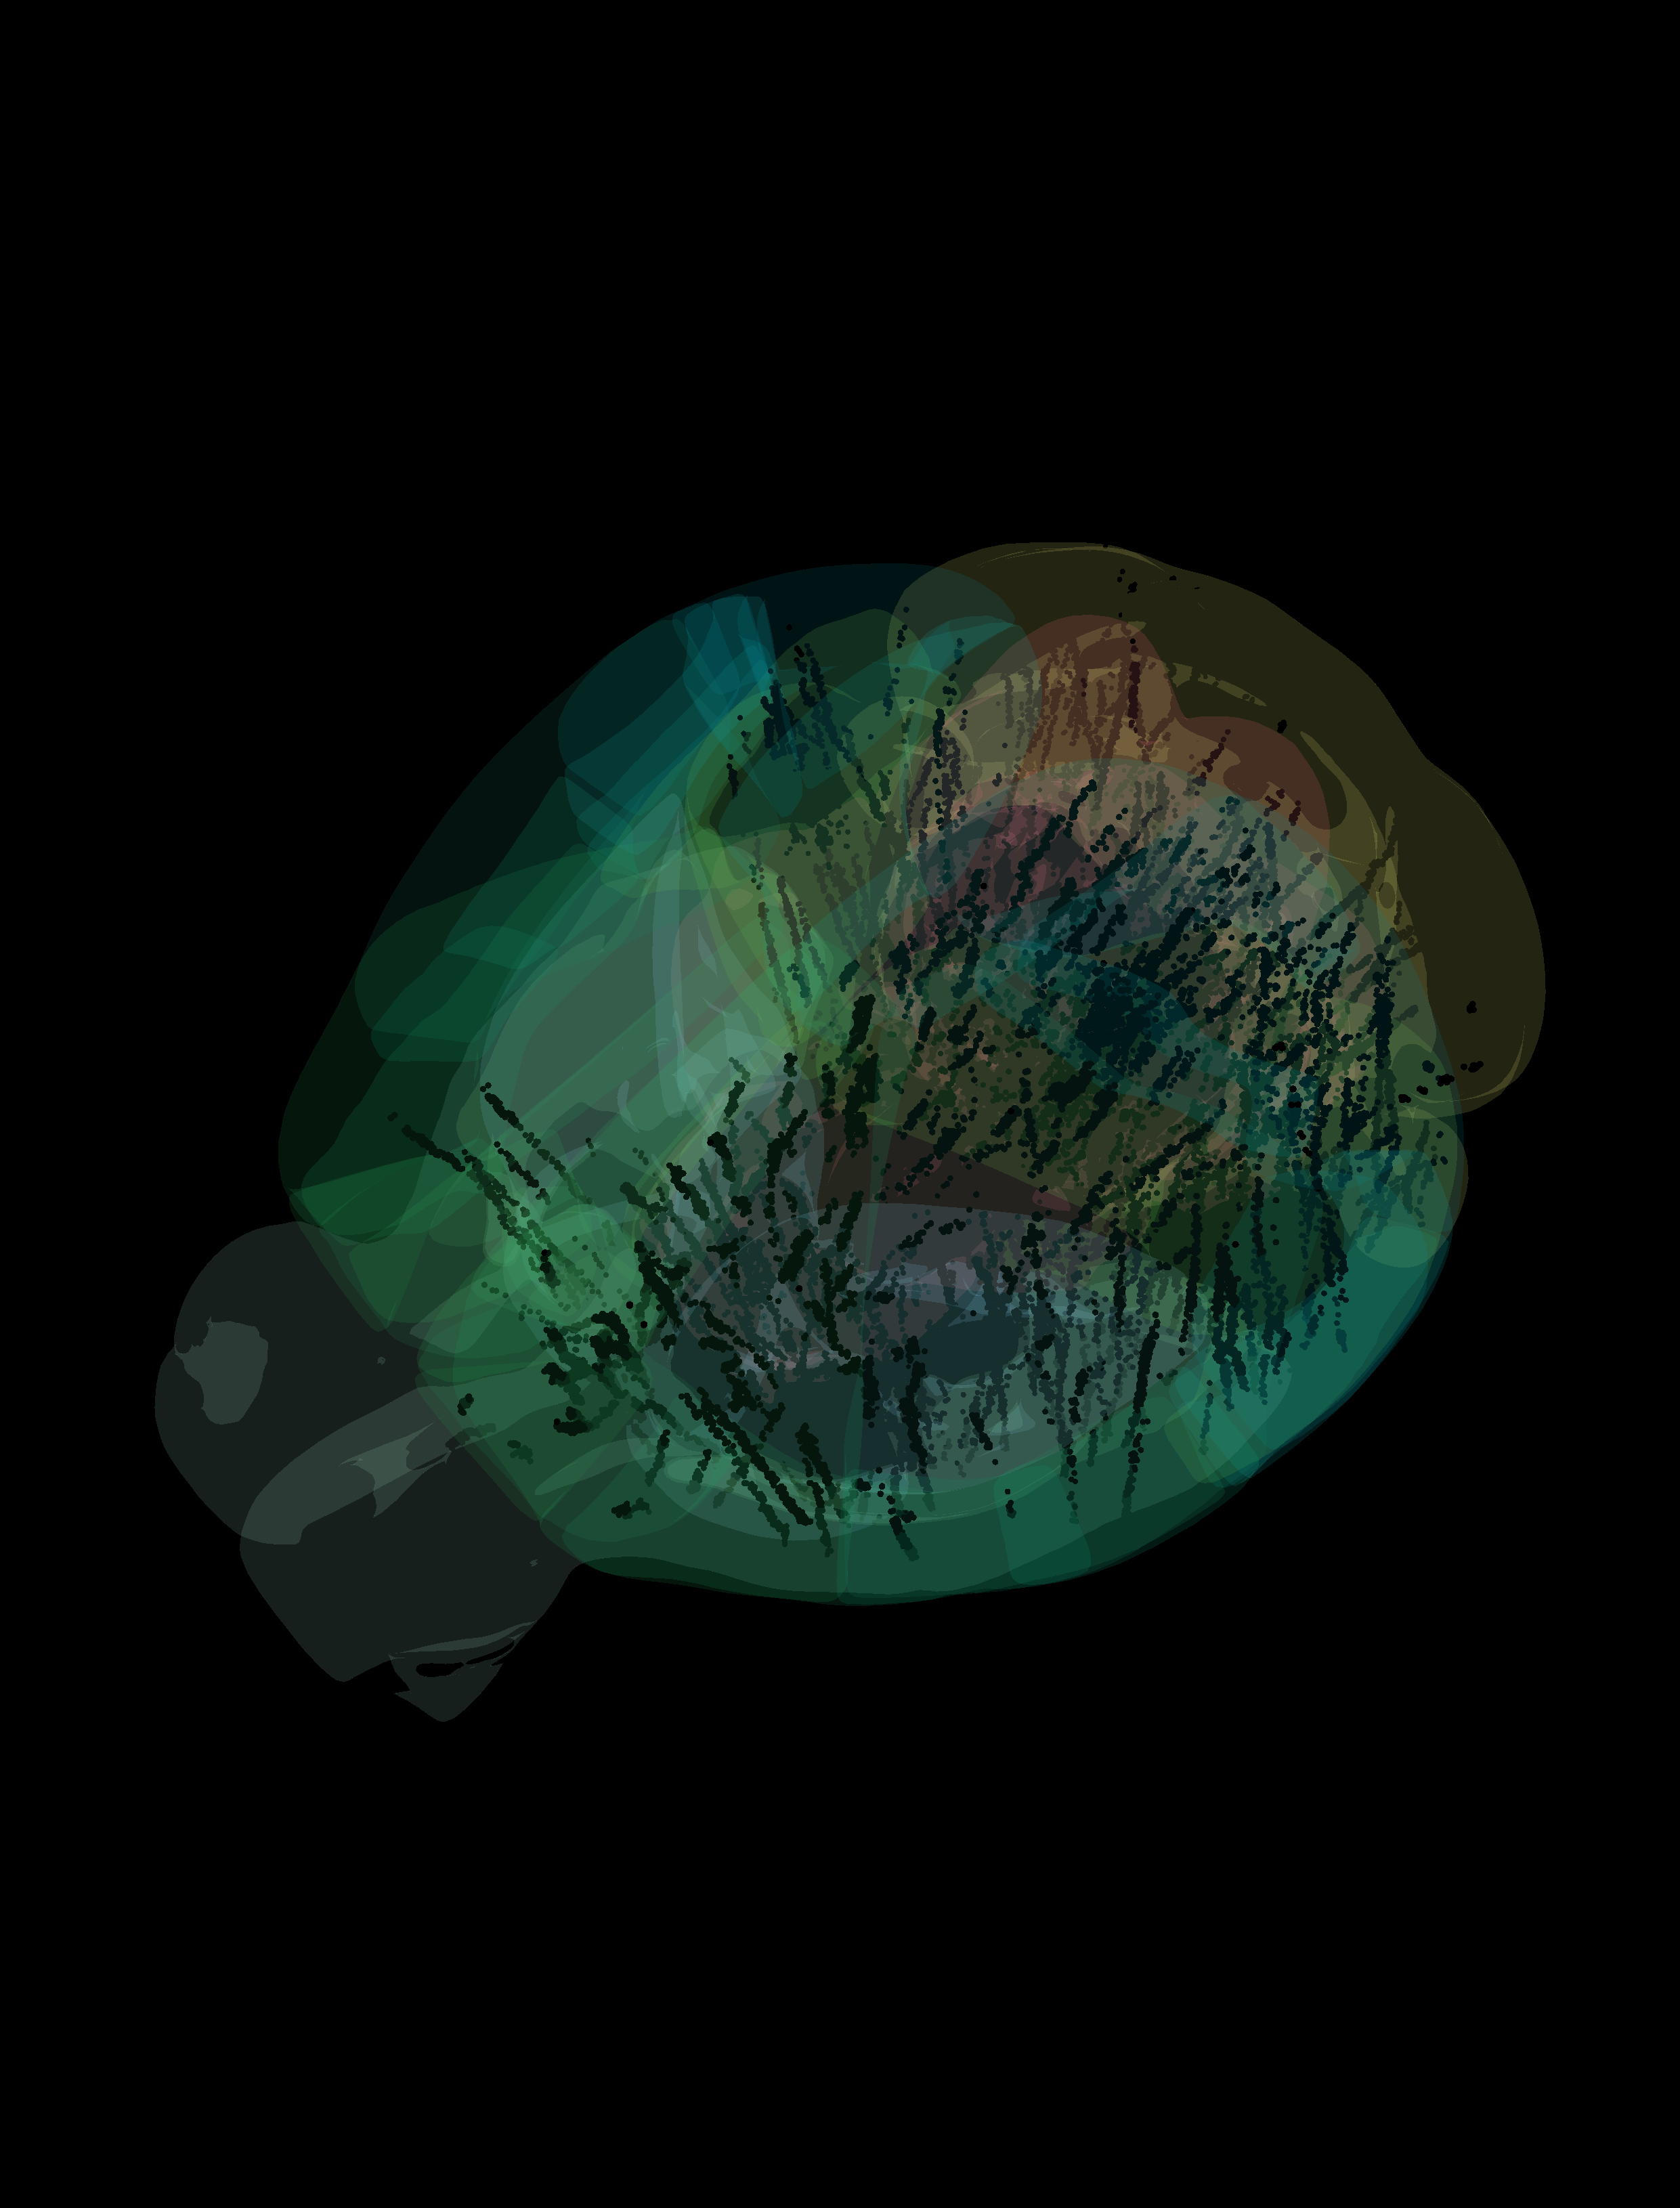

In [109]:
urchin.camera.main.set_background_color("#000000")
urchin.camera.main.set_rotation('angled')
urchin.camera.main.set_mode("perspective")
urchin.camera.main.set_zoom(70)
await urchin.camera.main.screenshot(size=[2481 ,3261 ])